### 기본 라이브러리 불러오기

In [1]:
# Pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
!pip install torchinfo
from torchinfo import summary
from torch.utils.data import Subset
# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

Source code :  
https://docs.pytorch.org/vision/0.8/_modules/torchvision/models/resnet.html
https://github.com/tony9402/pytorch_models/blob/main/src/models/resnet.py

### 순서
#### 1. ResNet 모델 구축
#### 2. 데이터셋 준비
#### 3. Resnet 모델(34, 50)간의 성능 비교
    3-1 ResNet-34 학습
    3-2 ResNet-50 학습
#### 4. Train loss(훈련손실) 비교
#### 5. Validation accuracy(검증 정확도)
#### 6. PlainNet 일반네트워크 만들기
#### 7. PlainNet 모델(34, 50)간의 성능 비교
    7-1 PlainNet-34 학습
    7-2 PlainNet-50 학습
#### 8. PlainNet vs ResNet 비교

### 1. ResNet 모델 구축

In [2]:
def conv3x3(in_planes, out_planes, stride, padding=1, bias = False):
    return nn.Conv2d(in_planes, out_planes, \
        kernel_size = 3,                    \
        stride      = stride,               \
        padding     = padding,              \
        bias        = bias
    )

def conv1x1(in_planes, out_planes, stride, padding=0, bias = False):
    return nn.Conv2d(in_planes, out_planes, \
        kernel_size = 1,                    \
        stride      = stride,               \
        padding     = padding,              \
        bias        = bias
    )


In [3]:
class BasicBlock(nn.Module):
    mul = 1
    def __init__(self, in_planes, out_planes, stride = 1):
        super(BasicBlock, self).__init__()

        self.conv1 = conv3x3(in_planes, out_planes, stride)
        self.conv2 = conv3x3(out_planes, out_planes, 1)

        self.bn1   = nn.BatchNorm2d(out_planes)
        self.bn2   = nn.BatchNorm2d(out_planes)

        self.shortcut = nn.Sequential()
        if stride != 1:
            self.shortcut = nn.Sequential(
                conv1x1(in_planes, out_planes, stride),
                nn.BatchNorm2d(out_planes)
            )

    def forward(self, x):
        out  = self.conv1(x)
        out  = self.bn1(out)
        out  = F.relu(out)
        out  = self.conv2(out)
        out  = self.bn2(out)
        out += self.shortcut(x)
        out  = F.relu(out)
        return out

In [4]:
class BottleNect(nn.Module):
    mul = 4
    def __init__(self, in_planes, out_planes, stride = 1):
        super(BottleNect, self).__init__()

        self.conv1 = conv1x1(in_planes, out_planes, stride)
        self.conv2 = conv3x3(out_planes, out_planes, 1, 1)
        self.conv3 = conv1x1(out_planes, out_planes * self.mul, 1)

        self.bn1   = nn.BatchNorm2d(out_planes)
        self.bn2   = nn.BatchNorm2d(out_planes)
        self.bn3   = nn.BatchNorm2d(out_planes * self.mul)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != out_planes * self.mul:
            self.shortcut = nn.Sequential(
                conv1x1(in_planes, out_planes * self.mul, stride),
                nn.BatchNorm2d(out_planes * self.mul)
            )

    def forward(self, x):
        out  = self.conv1(x)
        out  = self.bn1(out)
        out  = F.relu(out)
        out  = self.conv2(out)
        out  = self.bn2(out)
        out  = F.relu(out)
        out  = self.conv3(out)
        out  = self.bn3(out)
        out += self.shortcut(x)
        out  = F.relu(out)
        return out

In [5]:
class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes = 37):
        super(ResNet, self).__init__()

        # 7x7, 64 channels, stride 2 in paper
        self.in_planes = 64 

        # RGB channel -> 64 channels
        self.conv    = nn.Conv2d(3, self.in_planes, kernel_size = 7, stride = 2, padding = 3)
        self.bn      = nn.BatchNorm2d(self.in_planes)
        self.maxpool = nn.MaxPool2d(kernel_size = 3, stride = 2, padding = 1)

        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.linear  = nn.Linear(512 * block.mul, num_classes)

    def _make_layer(self, block, out_planes, num_block, stride):
        layers  = [ block(self.in_planes, out_planes, stride) ]
        self.in_planes = block.mul * out_planes
        for i in range(num_block - 1):
            layers.append(block(self.in_planes, out_planes, 1))

        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv(x)
        out = self.bn(out)
        out = F.relu(out)
        out = self.maxpool(out)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.linear(out)
        return out

In [6]:
def ResNet34():
    return ResNet(BasicBlock, [3, 4, 6, 3])

def ResNet50():
    return ResNet(BottleNect, [3, 4, 6, 3])

In [7]:
resnet_34 = ResNet34()
summary(resnet_34, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 37]                   --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,472
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─MaxPool2d: 1-3                         [1, 64, 56, 56]           --
├─Sequential: 1-4                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─Conv2d: 3-3                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-4             [1, 64, 56, 56]           128
│    │    └─Sequential: 3-5              [1, 64, 56, 56]           --
│    └─BasicBlock: 2-2                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-6                  [1, 64, 56, 56]           36,8

In [8]:
resnet_50 = ResNet50()
summary(resnet_50, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 37]                   --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,472
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─MaxPool2d: 1-3                         [1, 64, 56, 56]           --
├─Sequential: 1-4                        [1, 256, 56, 56]          --
│    └─BottleNect: 2-1                   [1, 256, 56, 56]          --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─Conv2d: 3-3                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-4             [1, 64, 56, 56]           128
│    │    └─Conv2d: 3-5                  [1, 256, 56, 56]          16,384
│    │    └─BatchNorm2d: 3-6             [1, 256, 56, 56]          512
│    │    └─Sequential: 3-7              [1, 256, 56, 56]          

#### RuntimeError: CUDA error: device-side assert triggered 오류 해결
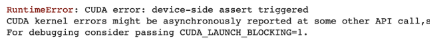

해결 1 ) 링크 : https://chanmuzi.tistory.com/344#google_vignette

해결 2 ) 주피터 노트북 상단에서 [Kernel] -> [Restart] 를 누릅니다.

### 2. 데이터셋 준비

In [10]:
transform = transforms.Compose([
    # OxfordIIITPet은 사진 크기가 제각각이라, 모델(ResNet)에 맞게 크기를 통일해주는 게 좋습니다.
    transforms.Resize((224, 224)), 
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.OxfordIIITPet(root='./data', split='trainval', download=True, transform=transform)
testset = torchvision.datasets.OxfordIIITPet(root='./data', split='test', download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

In [11]:
# 데이터셋을 로드하고 기본 정보를 확인해 보세요.
image, label = trainset[0]

print(f"Image shape: {image.shape}")
print(f"Label: {label}")
print(f"Number of classes: {len(trainset.classes)}")

Image shape: torch.Size([3, 224, 224])
Label: 0
Number of classes: 37


3채널, 224 x 224 픽셀의 컬러이미지이며 10개 클래스를 가지고 있음

In [12]:
# 데이터의 개수도 확인해 봅시다.
train_size = torch.tensor(len(trainset))
test_size = torch.tensor(len(testset))

print(f"Train dataset size: {train_size} (Shape: {train_size.shape})")
print(f"Test dataset size: {test_size} (Shape: {test_size.shape})")

Train dataset size: 3680 (Shape: torch.Size([]))
Test dataset size: 3669 (Shape: torch.Size([]))


In [13]:
# Q. 이미지의 표현이 0과 1 사이로 들어오도록 직접 Pytorch 정규화 코드를 작성해봅시다.
transform = transforms.Compose([
    transforms.ToTensor()  # uint8 → float32 변환 + 0~1 정규화
])

In [14]:
# 클래스 수, 종류 확인
num_classes = len(trainset.classes)
print(num_classes)
class_names = trainset.classes
print(class_names)

37
['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair', 'Chihuahua', 'Egyptian Mau', 'English Cocker Spaniel', 'English Setter', 'German Shorthaired', 'Great Pyrenees', 'Havanese', 'Japanese Chin', 'Keeshond', 'Leonberger', 'Maine Coon', 'Miniature Pinscher', 'Newfoundland', 'Persian', 'Pomeranian', 'Pug', 'Ragdoll', 'Russian Blue', 'Saint Bernard', 'Samoyed', 'Scottish Terrier', 'Shiba Inu', 'Siamese', 'Sphynx', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier']


In [15]:
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    return np.transpose(npimg, (1, 2, 0))

In [16]:
def show_multiple_images(dataset, n_images=9):
    dataiter = iter(dataset)
    images, labels = next(dataiter)
    fig, axes = plt.subplots(3, 3, figsize=(6, 6))
    axes = axes.flatten()

    for i in range(n_images):
        ax = axes[i]
        img = imshow(images[i])
        ax.imshow(img)
        ax.set_title(f"Label: {trainset.classes[labels[i]]}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

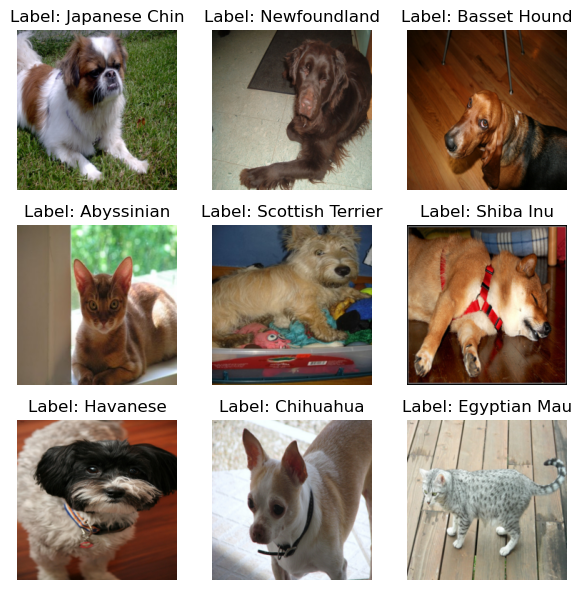

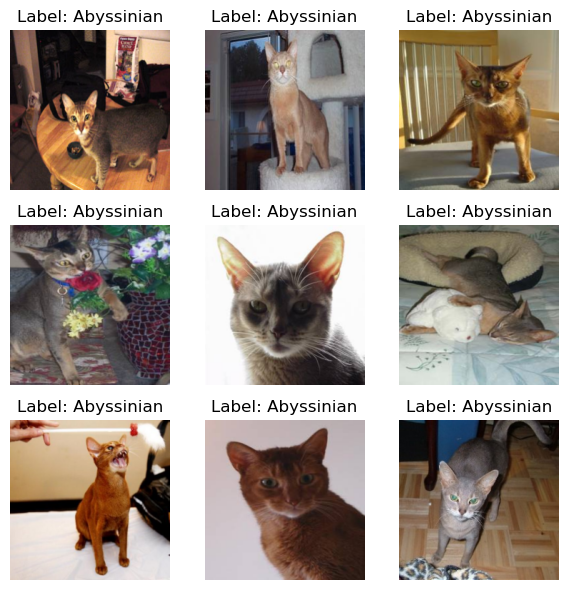

In [17]:
# train과 test 데이터셋에서 9개의 이미지를 시각화합니다.
show_multiple_images(trainloader)
show_multiple_images(testloader)

### 3. Resnet 모델(34, 50)간의 성능 비교

In [18]:
BATCH_SIZE = 32 # 이게 의미가 있나? 아까 trainloder에 들어가 있는데
EPOCH = 10

#### 3-1 ResNet-34 학습 진행

In [19]:
import time

current_time = time.time()

# 모델 준비
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet_34 = ResNet34() # 직접 만든 모델 호출
resnet_34.to(device)

# 모든 파라미터를 학습 가능하게 설정 (Fine-tuning 준비)
for param in resnet_34.parameters():
    param.requires_grad = True

# 손실 함수와 최적화 도구 설정
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet_34.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

# 결과를 담을 리스트 이름 변경
resnet_34_train_losses = []
resnet_34_val_accuracy = []

for epoch in range(EPOCH):
    resnet_34.train() # 학습 모드 시작
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()      # 기울기 초기화
        outputs = resnet_34(inputs) # 모델 통과
        loss = criterion(outputs, labels) # 오차 계산
        loss.backward()            # 역전파
        optimizer.step()           

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 100 == 99:    # 100번째 묶음(Batch)마다 진행 상황 출력
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / (i + 1):.3f}")
            
    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total
    resnet_34_train_losses.append(train_loss)

    print(f"Epoch {epoch + 1}: Train Accuracy: {train_acc:.2f}%")

    # 4. 검증 단계 (Validation)
    resnet_34.eval() 
    correct = 0
    total = 0

    with torch.no_grad(): 
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = resnet_34(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    resnet_34_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")
print(f"Total Training Time: {time.time() - current_time:.2f} seconds")

[1,   100] loss: 3.573
Epoch 1: Train Accuracy: 6.06%
Epoch 1: Validation Accuracy: 7.36%
[2,   100] loss: 3.261
Epoch 2: Train Accuracy: 11.77%
Epoch 2: Validation Accuracy: 10.52%
[3,   100] loss: 2.998
Epoch 3: Train Accuracy: 17.50%
Epoch 3: Validation Accuracy: 12.65%
[4,   100] loss: 2.723
Epoch 4: Train Accuracy: 23.56%
Epoch 4: Validation Accuracy: 14.42%
[5,   100] loss: 2.454
Epoch 5: Train Accuracy: 30.41%
Epoch 5: Validation Accuracy: 16.22%
[6,   100] loss: 2.147
Epoch 6: Train Accuracy: 38.48%
Epoch 6: Validation Accuracy: 15.32%
[7,   100] loss: 1.788
Epoch 7: Train Accuracy: 47.28%
Epoch 7: Validation Accuracy: 15.51%
[8,   100] loss: 1.429
Epoch 8: Train Accuracy: 58.21%
Epoch 8: Validation Accuracy: 14.47%
[9,   100] loss: 1.043
Epoch 9: Train Accuracy: 70.00%
Epoch 9: Validation Accuracy: 11.37%
[10,   100] loss: 0.661
Epoch 10: Train Accuracy: 83.10%
Epoch 10: Validation Accuracy: 20.82%
Finished Training
Total Training Time: 580.59 seconds


#### 3-2 ResNet-50 학습 진행

In [20]:
import time

current_time = time.time()

#  모델 준비 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet_50 = ResNet50() 
resnet_50.to(device)

# 모든 파라미터를 학습 가능하게 설정 (Fine-tuning 준비)
for param in resnet_50.parameters():
    param.requires_grad = True

# 손실 함수와 최적화 도구 설정
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet_50.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

# 결과를 담을 리스트 이름 변경
resnet_50_train_losses = []
resnet_50_val_accuracy = []

for epoch in range(EPOCH):
    resnet_50.train() # 학습 모드 시작
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()      # 기울기 초기화
        outputs = resnet_50(inputs) # 모델 통과
        loss = criterion(outputs, labels) # 오차 계산
        loss.backward()            # 역전파
        optimizer.step()          

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 100 == 99:    # 100번째 묶음(Batch)마다 진행 상황 출력
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / (i + 1):.3f}")
            
    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total
    resnet_50_train_losses.append(train_loss)

    print(f"Epoch {epoch + 1}: Train Accuracy: {train_acc:.2f}%")

    # 4. 검증 단계 (Validation)
    resnet_50.eval() 
    correct = 0
    total = 0

    with torch.no_grad(): 
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = resnet_50(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    resnet_50_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")
print(f"Total Training Time: {time.time() - current_time:.2f} seconds")

[1,   100] loss: 3.755
Epoch 1: Train Accuracy: 3.04%
Epoch 1: Validation Accuracy: 3.60%
[2,   100] loss: 3.657
Epoch 2: Train Accuracy: 5.05%
Epoch 2: Validation Accuracy: 6.84%
[3,   100] loss: 3.492
Epoch 3: Train Accuracy: 7.93%
Epoch 3: Validation Accuracy: 6.65%
[4,   100] loss: 3.348
Epoch 4: Train Accuracy: 10.46%
Epoch 4: Validation Accuracy: 10.22%
[5,   100] loss: 3.180
Epoch 5: Train Accuracy: 13.80%
Epoch 5: Validation Accuracy: 11.56%
[6,   100] loss: 3.022
Epoch 6: Train Accuracy: 16.88%
Epoch 6: Validation Accuracy: 10.93%
[7,   100] loss: 2.845
Epoch 7: Train Accuracy: 20.73%
Epoch 7: Validation Accuracy: 12.89%
[8,   100] loss: 2.633
Epoch 8: Train Accuracy: 24.57%
Epoch 8: Validation Accuracy: 13.90%
[9,   100] loss: 2.543
Epoch 9: Train Accuracy: 27.69%
Epoch 9: Validation Accuracy: 17.09%
[10,   100] loss: 2.302
Epoch 10: Train Accuracy: 33.18%
Epoch 10: Validation Accuracy: 14.96%
Finished Training
Total Training Time: 762.59 seconds


### 4. Train loss(훈련손실) 비교

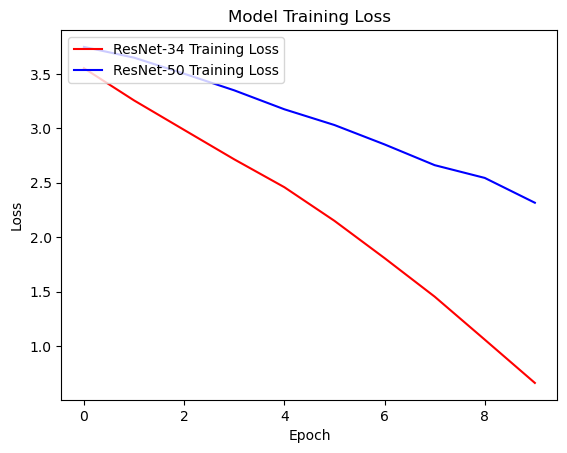

In [24]:
import matplotlib.pyplot as plt

plt.plot(resnet_34_train_losses, 'r', label="ResNet-34 Training Loss")
plt.plot(resnet_50_train_losses, 'b', label="ResNet-50 Training Loss")

plt.title('Model Training Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

### 5. Validation accuracy(검증 정확도)

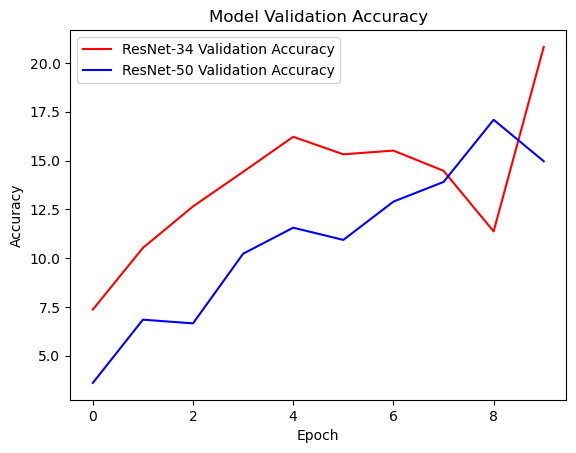

In [25]:
plt.plot(resnet_34_val_accuracy, 'r', label="ResNet-34 Validation Accuracy")
plt.plot(resnet_50_val_accuracy, 'b', label="ResNet-50 Validation Accuracy")

plt.title('Model Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

### 6. 일반 네트워크 만들기(PlainNet-34 , PlainNet-50)

In [30]:
import torch.nn as nn

def conv3x3(in_planes, out_planes, stride, padding=1, bias = False):
    return nn.Conv2d(in_planes, out_planes, \
        kernel_size = 3,                    \
        stride      = stride,               \
        padding     = padding,              \
        bias        = bias
    )

def conv1x1(in_planes, out_planes, stride, padding=0, bias = False):
    return nn.Conv2d(in_planes, out_planes, \
        kernel_size = 1,                    \
        stride      = stride,               \
        padding     = padding,              \
        bias        = bias
    )

class PlainBlock(nn.Module):
    mul = 1
    def __init__(self, in_planes, out_planes, stride = 1):
        super(PlainBlock, self).__init__()

        self.conv1 = conv3x3(in_planes, out_planes, stride)
        self.conv2 = conv3x3(out_planes, out_planes, 1)

        self.bn1   = nn.BatchNorm2d(out_planes)
        self.bn2   = nn.BatchNorm2d(out_planes)


    def forward(self, x):
        out  = self.conv1(x)
        out  = self.bn1(out)
        out  = F.relu(out)
        out  = self.conv2(out)
        out  = self.bn2(out)
        out  = F.relu(out)
        return out

class PlainBottleNect(nn.Module):
    mul = 4
    def __init__(self, in_planes, out_planes, stride = 1):
        super(PlainBottleNect, self).__init__()

        self.conv1 = conv1x1(in_planes, out_planes, stride)
        self.conv2 = conv3x3(out_planes, out_planes, 1, 1)
        self.conv3 = conv1x1(out_planes, out_planes * self.mul, 1)

        self.bn1   = nn.BatchNorm2d(out_planes)
        self.bn2   = nn.BatchNorm2d(out_planes)
        self.bn3   = nn.BatchNorm2d(out_planes * self.mul)

    def forward(self, x):
        out  = self.conv1(x)
        out  = self.bn1(out)
        out  = F.relu(out)
        out  = self.conv2(out)
        out  = self.bn2(out)
        out  = F.relu(out)
        out  = self.conv3(out)
        out  = self.bn3(out)
        out  = F.relu(out)
        return out

class PlainNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes = 37):
        super(PlainNet, self).__init__()

        # 7x7, 64 channels, stride 2 in paper
        self.in_planes = 64 

        # RGB channel -> 64 channels
        self.conv    = nn.Conv2d(3, self.in_planes, kernel_size = 7, stride = 2, padding = 3)
        self.bn      = nn.BatchNorm2d(self.in_planes)
        self.maxpool = nn.MaxPool2d(kernel_size = 3, stride = 2, padding = 1)

        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.linear  = nn.Linear(512 * block.mul, num_classes)

    def _make_layer(self, block, out_planes, num_block, stride):
        layers  = [ block(self.in_planes, out_planes, stride) ]
        self.in_planes = block.mul * out_planes
        for i in range(num_block - 1):
            layers.append(block(self.in_planes, out_planes, 1))

        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv(x)
        out = self.bn(out)
        out = F.relu(out)
        out = self.maxpool(out)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.linear(out)
        return out

def PlainNet34():
    return PlainNet(PlainBlock, [3, 4, 6, 3])

def PlainNet50():
    return PlainNet(PlainBottleNect, [3, 4, 6, 3])

In [31]:
plainnet_34 = PlainNet34()
summary(plainnet_34, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
PlainNet                                 [1, 37]                   --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,472
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─MaxPool2d: 1-3                         [1, 64, 56, 56]           --
├─Sequential: 1-4                        [1, 64, 56, 56]           --
│    └─PlainBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─Conv2d: 3-3                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-4             [1, 64, 56, 56]           128
│    └─PlainBlock: 2-2                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-5                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-6             [1, 64, 56, 56]           

In [32]:
plainnet_50 = PlainNet50()
summary(plainnet_50, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
PlainNet                                 [1, 37]                   --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,472
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─MaxPool2d: 1-3                         [1, 64, 56, 56]           --
├─Sequential: 1-4                        [1, 256, 56, 56]          --
│    └─PlainBottleNect: 2-1              [1, 256, 56, 56]          --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─Conv2d: 3-3                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-4             [1, 64, 56, 56]           128
│    │    └─Conv2d: 3-5                  [1, 256, 56, 56]          16,384
│    │    └─BatchNorm2d: 3-6             [1, 256, 56, 56]          512
│    └─PlainBottleNect: 2-2              [1, 256, 56, 56]          

### 7. PlainNet으로 데이터셋 학습 진행

### 7-1 PlainNet-34 학습

In [33]:
import time

current_time = time.time()

# 모델 준비 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plainnet_34 = PlainNet34() # 직접 만든 모델 호출
plainnet_34.to(device)

# 모든 파라미터를 학습 가능하게 설정 (Fine-tuning 준비)
for param in plainnet_34.parameters():
    param.requires_grad = True

# 손실 함수와 최적화 도구 설정
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(plainnet_34.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

# 결과를 담을 리스트 이름 변경
plainnet_34_train_losses = []
plainnet_34_val_accuracy = []

for epoch in range(EPOCH):
    plainnet_34.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()      # 기울기 초기화
        outputs = plainnet_34(inputs) # 모델 통과
        loss = criterion(outputs, labels) # 오차 계산
        loss.backward()            # 역전파
        optimizer.step()           

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 100 == 99:    # 100번째 묶음(Batch)마다 진행 상황 출력
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / (i + 1):.3f}")
            
    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total
    plainnet_34_train_losses.append(train_loss)

    print(f"Epoch {epoch + 1}: Train Accuracy: {train_acc:.2f}%")

    # 4. 검증 단계 (Validation)
    plainnet_34.eval() 
    correct = 0
    total = 0

    with torch.no_grad(): 
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = plainnet_34(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    plainnet_34_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")
print(f"Total Training Time: {time.time() - current_time:.2f} seconds")

[1,   100] loss: 3.637
Epoch 1: Train Accuracy: 2.93%
Epoch 1: Validation Accuracy: 3.38%
[2,   100] loss: 3.594
Epoch 2: Train Accuracy: 3.53%
Epoch 2: Validation Accuracy: 5.12%
[3,   100] loss: 3.508
Epoch 3: Train Accuracy: 5.62%
Epoch 3: Validation Accuracy: 6.08%
[4,   100] loss: 3.425
Epoch 4: Train Accuracy: 8.04%
Epoch 4: Validation Accuracy: 7.52%
[5,   100] loss: 3.322
Epoch 5: Train Accuracy: 9.78%
Epoch 5: Validation Accuracy: 8.69%
[6,   100] loss: 3.261
Epoch 6: Train Accuracy: 11.09%
Epoch 6: Validation Accuracy: 9.54%
[7,   100] loss: 3.193
Epoch 7: Train Accuracy: 12.85%
Epoch 7: Validation Accuracy: 10.38%
[8,   100] loss: 3.092
Epoch 8: Train Accuracy: 14.70%
Epoch 8: Validation Accuracy: 11.04%
[9,   100] loss: 3.006
Epoch 9: Train Accuracy: 16.88%
Epoch 9: Validation Accuracy: 11.28%
[10,   100] loss: 2.923
Epoch 10: Train Accuracy: 17.64%
Epoch 10: Validation Accuracy: 13.44%
Finished Training
Total Training Time: 568.35 seconds


### 7-2 PlainNet-50 학습

In [34]:
import time

current_time = time.time()

# 모델 준비 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plainnet_50 = PlainNet50()
plainnet_50.to(device)

# 모든 파라미터를 학습 가능하게 설정 (Fine-tuning 준비)
for param in plainnet_50.parameters():
    param.requires_grad = True

# 손실 함수와 최적화 도구 설정
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(plainnet_50.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

# 결과를 담을 리스트 이름 변경
plainnet_50_train_losses = []
plainnet_50_val_accuracy = []

for epoch in range(EPOCH):
    plainnet_50.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()      # 기울기 초기화
        outputs = plainnet_50(inputs) # 모델 통과
        loss = criterion(outputs, labels) # 오차 계산
        loss.backward()            # 역전파
        optimizer.step()           

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 100 == 99:    # 100번째 묶음(Batch)마다 진행 상황 출력
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / (i + 1):.3f}")
            
    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total
    plainnet_50_train_losses.append(train_loss)

    print(f"Epoch {epoch + 1}: Train Accuracy: {train_acc:.2f}%")

    # 4. 검증 단계 (Validation)
    plainnet_50.eval() 
    correct = 0
    total = 0

    with torch.no_grad(): 
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = plainnet_50(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    plainnet_50_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")
print(f"Total Training Time: {time.time() - current_time:.2f} seconds")

[1,   100] loss: 3.645
Epoch 1: Train Accuracy: 2.72%
Epoch 1: Validation Accuracy: 3.19%
[2,   100] loss: 3.627
Epoch 2: Train Accuracy: 3.23%
Epoch 2: Validation Accuracy: 2.59%
[3,   100] loss: 3.622
Epoch 3: Train Accuracy: 3.12%
Epoch 3: Validation Accuracy: 4.36%
[4,   100] loss: 3.584
Epoch 4: Train Accuracy: 4.40%
Epoch 4: Validation Accuracy: 3.33%
[5,   100] loss: 3.554
Epoch 5: Train Accuracy: 4.59%
Epoch 5: Validation Accuracy: 5.40%
[6,   100] loss: 3.526
Epoch 6: Train Accuracy: 6.39%
Epoch 6: Validation Accuracy: 4.85%
[7,   100] loss: 3.479
Epoch 7: Train Accuracy: 6.49%
Epoch 7: Validation Accuracy: 5.59%
[8,   100] loss: 3.431
Epoch 8: Train Accuracy: 7.77%
Epoch 8: Validation Accuracy: 5.94%
[9,   100] loss: 3.373
Epoch 9: Train Accuracy: 8.18%
Epoch 9: Validation Accuracy: 7.58%
[10,   100] loss: 3.324
Epoch 10: Train Accuracy: 9.81%
Epoch 10: Validation Accuracy: 7.99%
Finished Training
Total Training Time: 690.46 seconds


### 8. PlainNet vs ResNet

#### PlainNet-34 vs ResNet-34

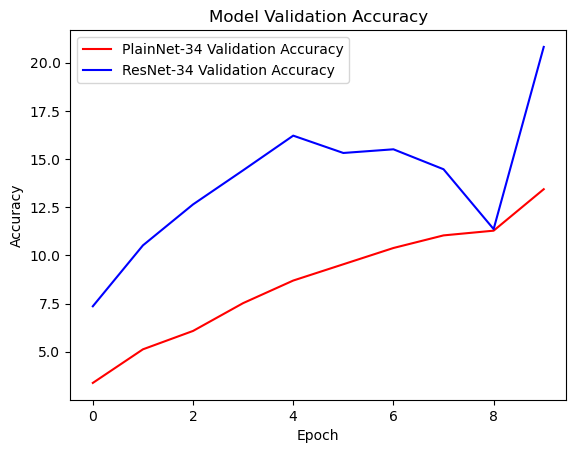

In [37]:
plt.plot(plainnet_34_val_accuracy, 'r', label="PlainNet-34 Validation Accuracy")
plt.plot(resnet_34_val_accuracy, 'b', label="ResNet-34 Validation Accuracy")

plt.title('Model Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

#### PlainNet-50 vs ResNet-50

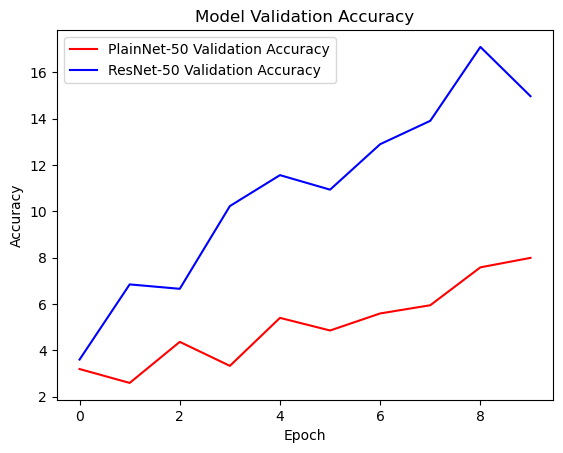

In [36]:
plt.plot(plainnet_50_val_accuracy, 'r', label="PlainNet-50 Validation Accuracy")
plt.plot(resnet_50_val_accuracy, 'b', label="ResNet-50 Validation Accuracy")

plt.title('Model Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

### 회고

- 모든 함수의 옵션들을 수정해서 결과를 보기에는 시간이 부족했다. 결과적으로 일반 네트워크보다 ResNet 모델의 성능이 더 좋은 것을 확인할 수 있었다.

- 그러나,  ResNet50이 ResNet34보다 loss 나 accuracy 값이 떨어진 것은 아직 의문이다.

  그렇다면
    1. 이미지 데이터 값이 부족했을까?
       : 아마도 이미지 데이터셋이 많거나 좀 더 복잡한(?)이미지일 수록 Epoch가 커지면 ResNet-50의 성능이 더 좋을 수도 있겠다. 초반에는 ResNet34의 성능이 좋을지라도. 추후에 데이터셋을 바꿔서 해볼만 하다.
       
    2. batch size 또는 epoch 값을 더 줄였어야 했나?
       : batch size를 16까지 줄여봤지만 결과는 ResNet-34의 모델 성능이 더 좋았고 epoch 값은 큰 영향은 없었다
 
    3. training set 과 test set 비율을 설정하는 코드가 필요했을까
       : LMS에서는 따로 설명이 없었던 것 같다. 만약에 9:1 8:2 등 설정을 해서 결과를 받아볼 필요는 있을 것 같다.
       : 아니면 torch에서 받은 데이터셋은 애초에 Train과 Test를 나눠줘서 그런건가 싶다.